In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
import gc
from mnp.ingestion.loader import load_endes
from IPython.display import display

from mnp.utils.profiler import centrar_notebook
centrar_notebook()

# Carga de historial desde 2007 para RECH1
history = load_endes(
        year=range(2007, 2025),
        module="household",
        record="household_roster",
        meta=True
    )
knowns_id = []
frames = []
latest_year_labels = {}
col_labels_hist = {}
value_labels_history = {}

for year in sorted(list(history.keys())):
    year_df, year_meta = history.pop(year)
    frames.append(year_df.assign(year=year))
    latest_year_labels.update(year_meta.column_names_to_labels)
    col_labels_hist[year] = year_meta.column_names_to_labels
    value_labels_history[year] = year_meta.variable_value_labels

df_rech1 = pd.concat(frames, ignore_index=True)
del frames
gc.collect()

all_cols = set()
for cols in col_labels_hist.values():
    all_cols.update(cols)

print(f"Registros RECH1 totales: {len(df_rech1)}")
print(f"Columnas RECH1 totales: {df_rech1.shape[1]}")
df_rech1.head(3)

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k
2026-06-10 05:44:26.202 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /workspace


2026-06-10 05:44:26.702 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: household_roster]
2026-06-10 05:44:28.051 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: household_roster]
2026-06-10 05:44:29.084 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: household_roster]
2026-06-10 05:44:29.817 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH1.SAV desde Modulo64 [Alias: household_roster]
2026-06-10 05:44:30.534 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH1.sav desde Modulo64 [Alias: household_roster]
2026-06-10 05:44:31.242 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH1.sav desde Modulo64 [Alias: household_roster]
2026-06-10 05:44:32.008 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH1.SAV desde Modulo

,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,year,QH21A,QH21B,QH13A1,QH13A2,QH13A3,QH13A4,QH13A5,QH13A6A,QH13A6B,QH13A6C,QH13A6D,QH13A6,QH25A,QH25B,QH25CM,QH25CA,ID1
0,1 4,1.0,1.0,1.0,1.0,2.0,65.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 4,2.0,3.0,1.0,1.0,2.0,39.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 4,3.0,5.0,1.0,1.0,1.0,11.0,2.0,0.0,6.0,3.0,1.0,1.0,2.0,1.0,0.0,NaN,NaN,0.0,NaN,0.0,1.0,2.0,1.0,7.0,1.0,1.0,6.0,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.1. Schema Drift (Mutación de Column Labels)

In [2]:
# # 1. Importa la función que faltaba
# from mnp.utils.profiler import (
#     analyze_logical_types, 
#     print_schema_drift_report, 
#     print_val_drift_report,
#     analyze_schema_drift,
#     analyze_val_drift
# )
# known_ids = ["HHID", "HVIDX", "QH25A"]
# logical_types = analyze_logical_types(df_rech1, all_cols, value_labels_history, col_labels_hist, forced_ids=known_ids)

In [3]:
from mnp.utils.profiler import analyze_schema_drift, print_schema_drift_report

all_cols_sch, stable_schema, mutated_schema = analyze_schema_drift(col_labels_hist)
print_schema_drift_report(all_cols_sch, stable_schema, mutated_schema)

REPORTE GLOBAL DE MUTACIÓN DE DESCRIPCIONES DE COLUMNAS (COLUMN LABELS)

Total de columnas detectadas: 58

Descripciones estables: 16
QH21B (Apariciones: 1 años)
  - Años 2013                       : Recibe en escuela desayuno almuerzo Qali Warma?
QH13A1 (Apariciones: 5 años)
  - Años 2013-2017                  : Limitacion permanente para moverse
QH13A2 (Apariciones: 5 años)
  - Años 2013-2017                  : Limitacion permanente para ver
QH13A3 (Apariciones: 5 años)
  - Años 2013-2017                  : Limitacion permanente para oir
QH13A4 (Apariciones: 5 años)
  - Años 2013-2017                  : Limitacion permanente para hablar
QH13A5 (Apariciones: 5 años)
  - Años 2013-2017                  : Limitacion permanente para entender
QH13A6A (Apariciones: 2 años)
  - Años 2013-2014                  : Otra Limitacion permanente para actividad diarias
QH13A6B (Apariciones: 2 años)
  - Años 2013-2014                  : Otra Limitacion permanente para actividad diarias
QH13A6C (Apari

## 1.2. Schema Drift (Mutación de Value Labels)

In [4]:
from mnp.utils.profiler import analyze_val_drift, print_val_drift_report

all_val_cols, stable_val_labels, mutated_val_labels = analyze_val_drift(value_labels_history)
print_val_drift_report(all_val_cols, stable_val_labels, mutated_val_labels, latest_year_labels=latest_year_labels)

REPORTE GLOBAL DE MUTACIÓN DE ETIQUETAS DE VALORES (2007 - 2024)

Total de columnas con mapeo de valores detectadas: 52

Etiquetas de valores estables: 11
QH21B - Recibe en escuela desayuno almuerzo Qali Warma? (Apariciones: 1 años)
  - Años 2013                       : 1.0 (Si) | 2.0 (No) | 8.0 (No sabe)
QH13A1 - Limitacion permanente para moverse (Apariciones: 5 años)
  - Años 2013-2017                  : 1.0 (Si) | 2.0 (No) | 8.0 (No sabe)
QH13A2 - Limitacion permanente para ver (Apariciones: 5 años)
  - Años 2013-2017                  : 1.0 (Si) | 2.0 (No) | 8.0 (No sabe)
QH13A3 - Limitacion permanente para oir (Apariciones: 5 años)
  - Años 2013-2017                  : 1.0 (Si) | 2.0 (No) | 8.0 (No sabe)
QH13A4 - Limitacion permanente para hablar (Apariciones: 5 años)
  - Años 2013-2017                  : 1.0 (Si) | 2.0 (No) | 8.0 (No sabe)
QH13A5 - Limitacion permanente para entender (Apariciones: 5 años)
  - Años 2013-2017                  : 1.0 (Si) | 2.0 (No) | 8.0 (No sabe)
Q

## 1.5. Matriz Histórica de Variables (Evolución del Schema)

In [5]:
# Filas = Años, Columnas = Variables
df_history_matrix = pd.DataFrame(col_labels_hist).T.sort_index()

# Reemplazamos los valores por el nombre de la propia variable (si existe) o vacío si no existía ese año
for col in df_history_matrix.columns:
    df_history_matrix[col] = df_history_matrix[col].where(df_history_matrix[col].isna(), col)

df_history_matrix = df_history_matrix.fillna("")

display(df_history_matrix)

,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,QH21A,QH21B,QH13A1,QH13A2,QH13A3,QH13A4,QH13A5,QH13A6A,QH13A6B,QH13A6C,QH13A6D,QH13A6,QH25A,QH25B,QH25CM,QH25CA,ID1
2007,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,,,,,,,,,,,,,,,
2008,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,,,,,,,,,,,,,,,
2009,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,,,,,,,,,,,,,,,
2010,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,,,,,,,,,,,,,,,
2011,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,,,,,,,,,,,,,,,
2012,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,,,,,,,,,,,,,,,
2013,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,QH21A,QH21B,QH13A1,QH13A2,QH13A3,QH13A4,QH13A5,QH13A6A,QH13A6B,QH13A6C,QH13A6D,,,,,,
2014,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,QH13A1,QH13A2,QH13A3,QH13A4,QH13A5,QH13A6A,QH13A6B,QH13A6C,QH13A6D,,,,,,
2015,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,QH13A1,QH13A2,QH13A3,QH13A4,QH13A5,,,,,QH13A6,,,,,
2016,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,HV109,HV110,HV111,HV112,HV113,HV114,HV115,HV116,HV117,HV118,HV120,HV121,HV122,HV123,HV124,HV125,HV126,HV127,HV128,HV129,HV130,HV131,HV132,HV133,HV134,HV135,HV136,HV137,HV138,HV139,HV140,,,QH13A1,QH13A2,QH13A3,QH13A4,QH13A5,,,,,QH13A6,,,,,


## 2. Master Data Dictionary (Reporte Combinado)

In [6]:
import pandas as pd
from mnp.utils.profiler import (
    analyze_logical_types, metric_latest_label, metric_logical_type, 
    metric_pandas_dtype, metric_has_value_labels, metric_nulls, 
    metric_years_present, metric_total_years
)

# 💡 ENFOQUE HÍBRIDO: IDs locales o conocidos
known_ids = ["HHID", "HVIDX", "HV000", "HV001", "HV002", "HV003"]
logical_types_dict = analyze_logical_types(df_rech1, all_cols, value_labels_history, col_labels_hist, forced_ids=known_ids)

# 1. El DataFrame base son las variables originales
df_report = pd.DataFrame(index=sorted(list(all_cols)))
df_report.index.name = "Variable"

# 2. Los "Enchufes" explícitos usando el map() nativo de Pandas
df_report["Latest Column Label"] = df_report.index.map(lambda c: metric_latest_label(c, latest_year_labels))
df_report["Tipo Lógico"]         = df_report.index.map(lambda c: metric_logical_type(c, logical_types_dict))
df_report["Pandas Dtype"]        = df_report.index.map(lambda c: metric_pandas_dtype(c, df_rech1.dtypes))
df_report["Value Labels"]        = df_report.index.map(lambda c: metric_has_value_labels(c, value_labels_history))
df_report["Años Presente"]       = df_report.index.map(lambda c: metric_years_present(c, col_labels_hist))
df_report["Total Años"]          = df_report.index.map(lambda c: metric_total_years(c, col_labels_hist))
df_report["% Nulos"]             = df_report.index.map(lambda c: metric_nulls(c, df_rech1))

df_report.sort_values(by=["Tipo Lógico", "% Nulos"], ascending=[True, False], inplace=True)
display(df_report)

,Latest Column Label,Tipo Lógico,Pandas Dtype,Value Labels,Años Presente,Total Años,% Nulos
Variable,,,,,,,
HV118,Elegibilidad para entrevista de hombres,Categorical,float64,X,2007-2024,18,100.0
HV130,Member has been very sick for 3+ months last year,Categorical,float64,X,2007-2017,11,100.0
HV131,Mother has been very sick for 3+ months last year,Categorical,float64,X,2007-2017,11,100.0
HV132,Father has been very sick for 3+ months last year,Categorical,float64,X,2007-2017,11,100.0
HV133,Mother/father dead or been very sick for 3+ months,Categorical,float64,X,2007-2017,11,100.0
HV134,Both parents alive,Categorical,float64,X,2007-2017,11,100.0
HV135,Has brothers/sisters under 18 of the same father and mother,Categorical,float64,X,2007-2017,11,100.0
HV136,Brothers/sisters under 18 that don't live in household,Categorical,float64,X,2007-2017,11,100.0
HV137,Member has a blanket,Categorical,float64,X,2007-2017,11,100.0


## 3. Análisis de Nulos por Tipo Lógico
Al agrupar por Tipo Lógico universal (en lugar de categorías de negocio manuales), podemos aplicar reglas de limpieza automáticas más adelante.

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k



ANÁLISIS DE EVOLUCIÓN DE NULOS: IDENTIFIER


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HHID,Identificación Cuestionario del Hogar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HVIDX,Número de orden,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
QH25A,¿Cuál es su nacionalidad?,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


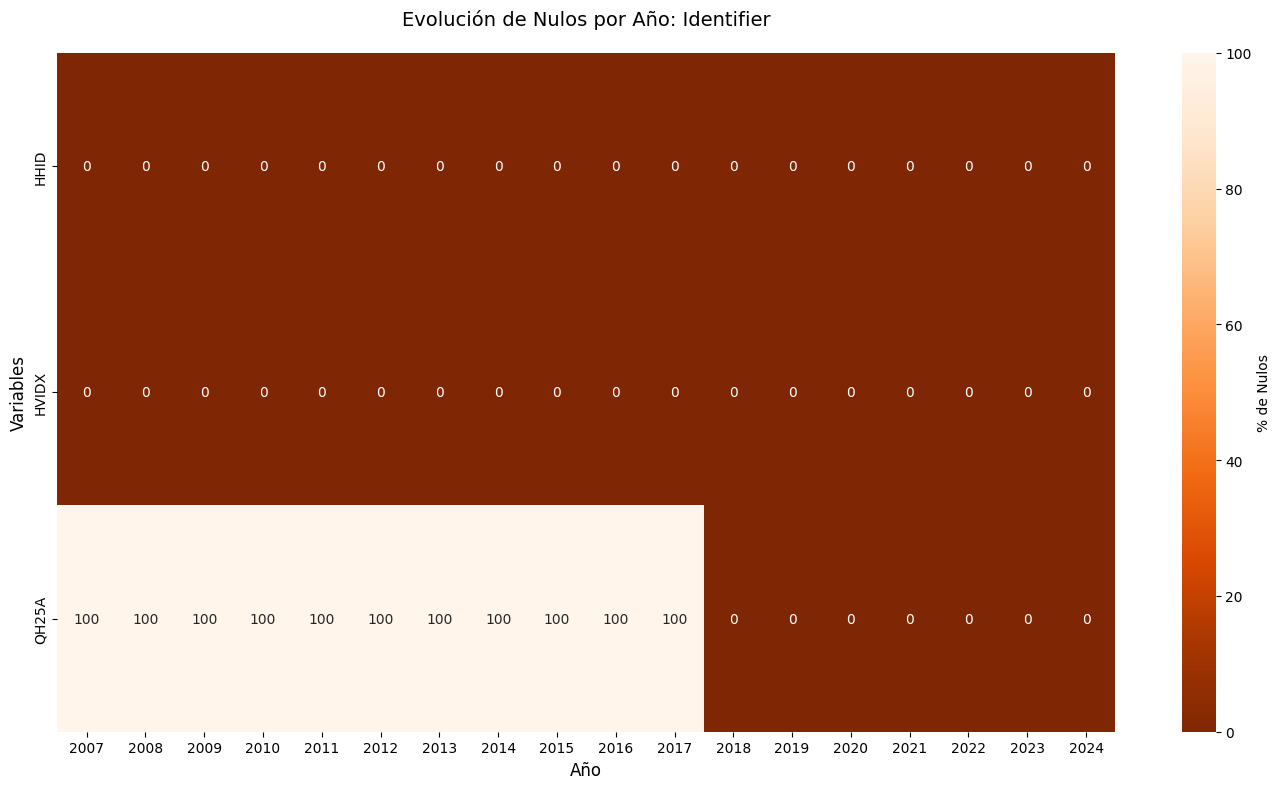

In [7]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech1, 
    cols=logical_types_dict.get("Identifier", []), 
    group_name="Identifier", 
    latest_year_labels=latest_year_labels, 
    cmap="Oranges_r", 
    figsize=(14, 8)
)



ANÁLISIS DE EVOLUCIÓN DE NULOS: CATEGORICAL


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HV101,Relación de parentesco con el jefe del hogar,0.001734,0.001419,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000661,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HV102,¿Vive habitualmente aquí?,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HV103,¿Durmió aquí anoche?,0.004336,0.002838,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HV104,Sexo,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HV105,Edad,0.000867,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HV106,¿Cuál fue el nivel de estudios más alto que aprobó?,0.032087,0.038318,0.000000,0.000000,0.000000,0.001938,0.000000,0.000000,0.021816,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HV107,¿Cuál fue el año o grado más alto que aprobó?,18.168416,17.849084,19.764315,19.076216,19.135027,19.017353,19.060113,18.476819,25.426564,24.622903,24.217272,24.807457,23.821836,21.267714,24.527360,24.162357,23.735981,23.254471
HV108,Número de años de estudio,0.044229,0.043285,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HV109,Nivel educativo alcanzado,0.032087,0.038318,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HV110,Actualmente ¿Asiste a una escuela o colegio (un instituto superior o universidad)?,0.050299,0.119921,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


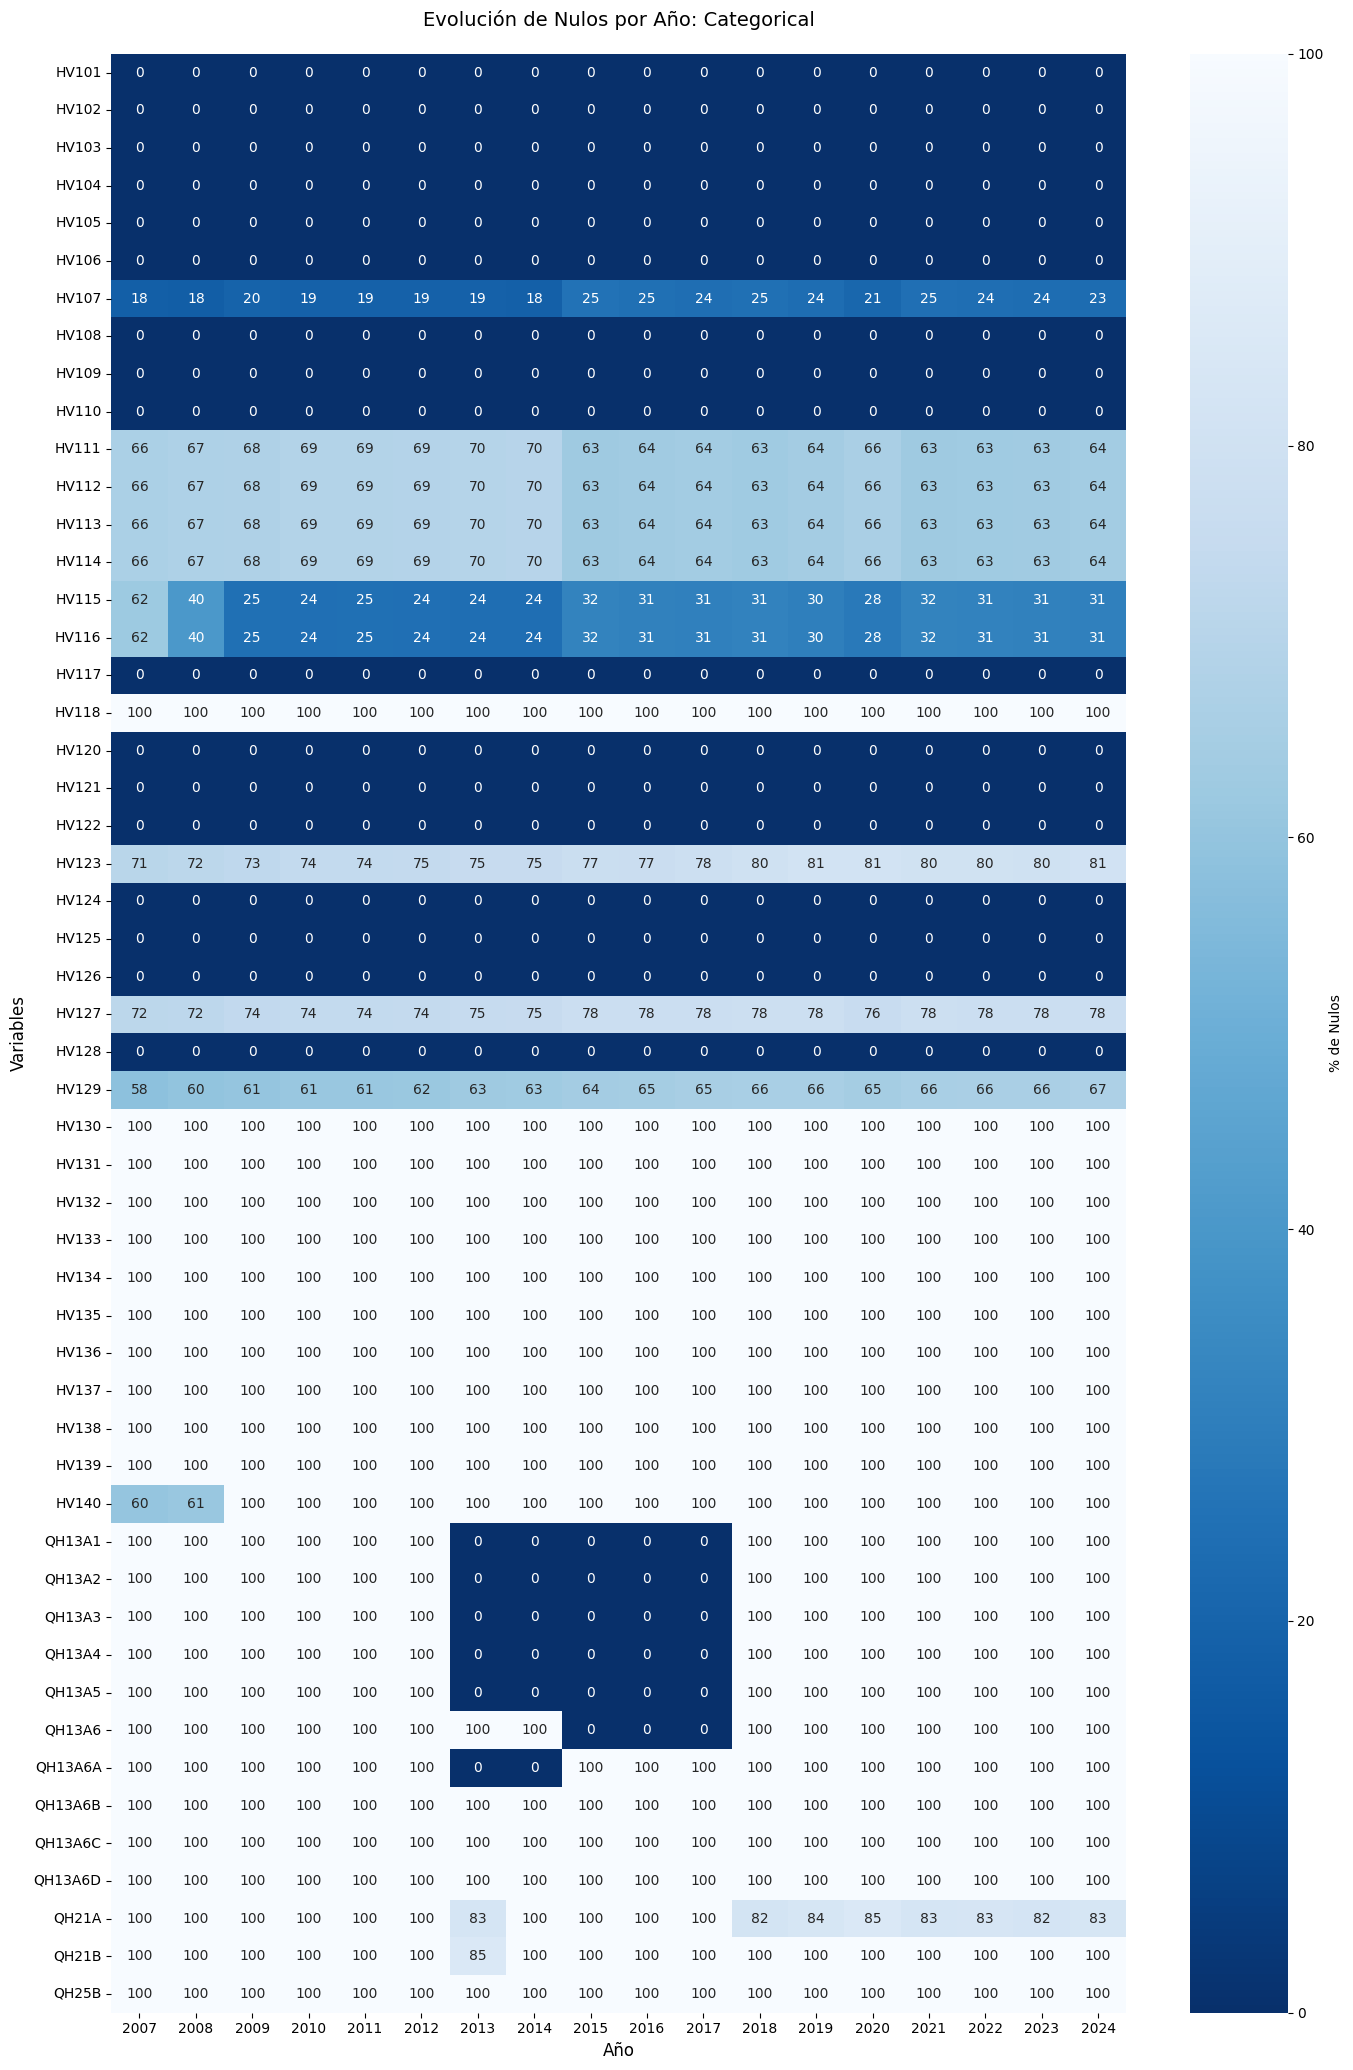

In [8]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech1, # (o df_rech1, df_rech0)
    cols=logical_types_dict.get("Categorical", []),
    group_name="Categorical",
    latest_year_labels=latest_year_labels,
    cmap="Blues_r",
    figsize=(14, 8)
)



ANÁLISIS DE EVOLUCIÓN DE NULOS: NUMERICAL


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
ID1,Año,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
QH25CA,Desde qué año vive en el Perú,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,99.743275,99.12535,99.382756,98.910719,98.748729,99.012766,98.918138
QH25CM,Desde qué mes vive en el Perú,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,99.743275,99.12535,99.382756,98.910719,98.748729,99.012766,98.918138


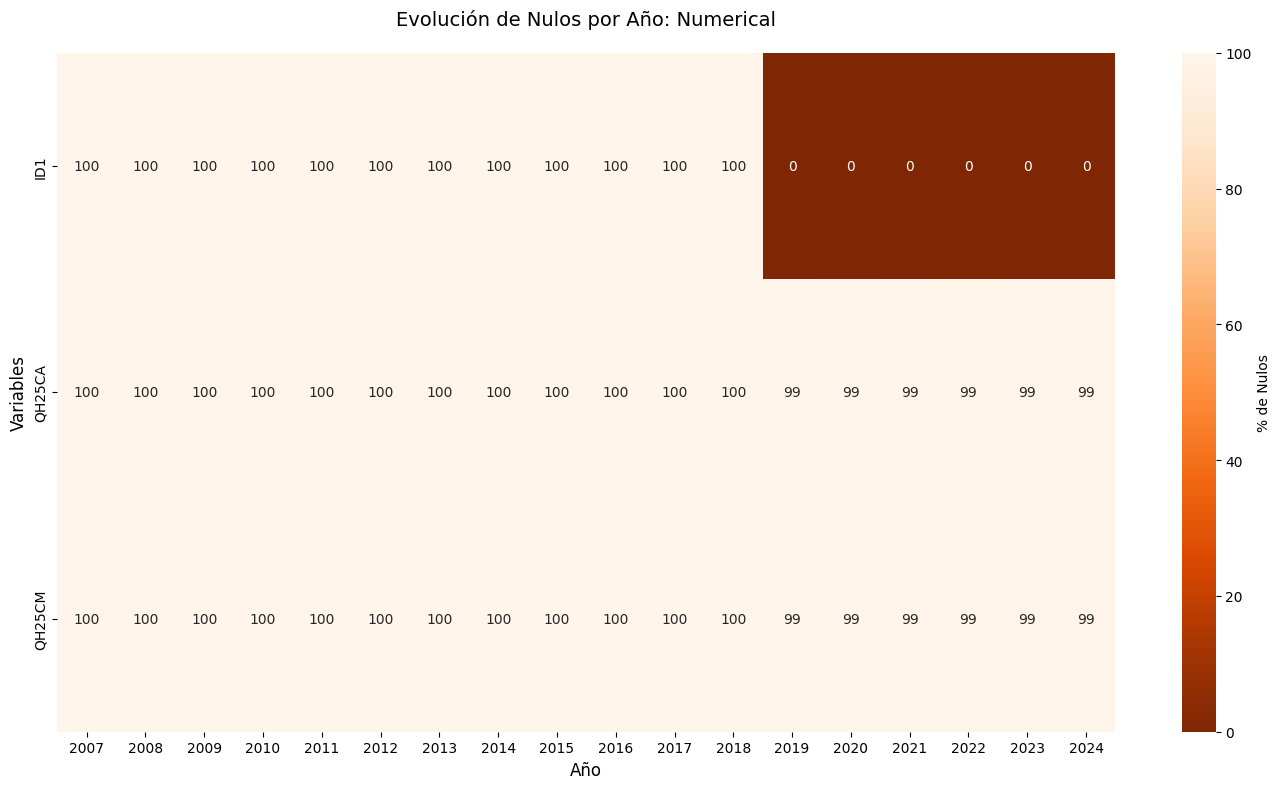

In [9]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech1, 
    cols=logical_types_dict.get("Numerical", []), 
    group_name="Numerical", 
    latest_year_labels=latest_year_labels, 
    cmap="Oranges_r", 
    figsize=(14, 8)
)
